In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
data=pd.read_csv("C:/Users/A/OneDrive/Desktop/Intenship/Womens Clothing E-Commerce Reviews.csv")
data.head(2)

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
0,0,767,33,NaN,Absolutely wonderful - silky and sexy and comf...,4,1,0,Initmates,Intimate,Intimates
1,1,1080,34,NaN,Love this dress! it's sooo pretty. i happene...,5,1,4,General,Dresses,Dresses


In [4]:
data.dropna(inplace=True)

In [5]:
data.isnull().sum()

Unnamed: 0                 0
Clothing ID                0
Age                        0
Title                      0
Review Text                0
Rating                     0
Recommended IND            0
Positive Feedback Count    0
Division Name              0
Department Name            0
Class Name                 0
dtype: int64

    Age Distribution Using Histogram

Text(0, 0.5, 'Count')

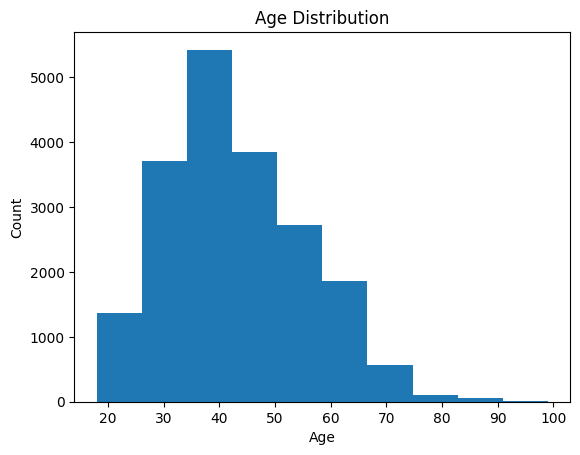

In [25]:
plt.hist(data["Age"])
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")


This code creates a histogram to visualize how the ages of your customers are spread out across the dataset.

    Bar Graph

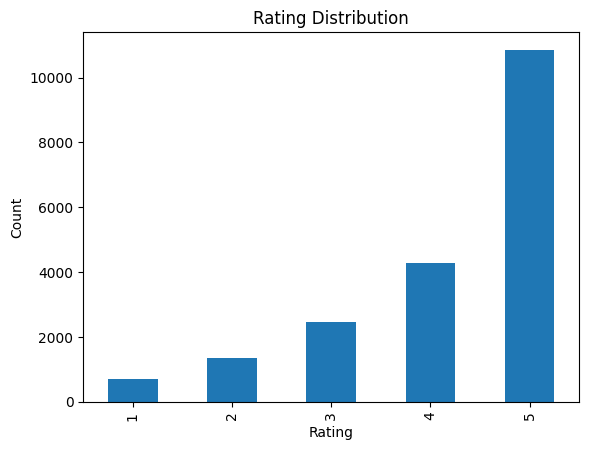

In [6]:
rating_counts = data["Rating"].value_counts().sort_index()

plt.figure()
rating_counts.plot(kind="bar")
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


This code creates a bar chart to show how many customers gave each specific rating (from 1 to 5 stars).

    Scatter Plot -:Rating vs Positive Feedback

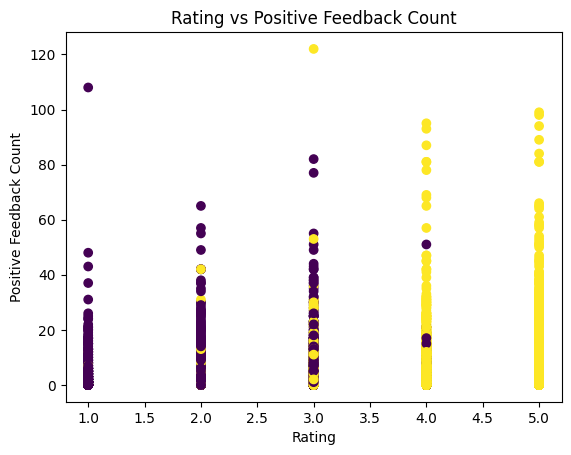

In [7]:

plt.scatter(data["Rating"], data["Positive Feedback Count"],c=data["Recommended IND"])# c means column.
plt.title("Rating vs Positive Feedback Count")
plt.xlabel("Rating")
plt.ylabel("Positive Feedback Count")
plt.show()





This code creates a scatter plot (a graph with many dots) to see if there is a connection between the stars a customer gives and how many other people liked that review.

    BoxPlot:- Rating by Recommendation

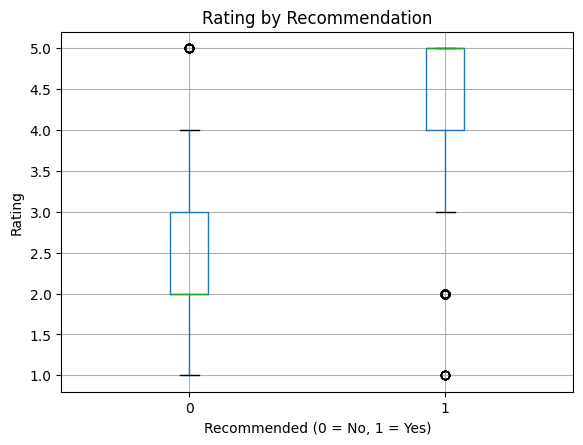

In [13]:
data.boxplot(column="Rating", by="Recommended IND")
plt.title("Rating by Recommendation")
plt.xlabel("Recommended (0 = No, 1 = Yes)")
plt.ylabel("Rating")
plt.suptitle("")
plt.show()

This code creates a boxplot to compare the range of ratings between products that were recommended and those that were not.

    Pie Chart : -  for Division Name

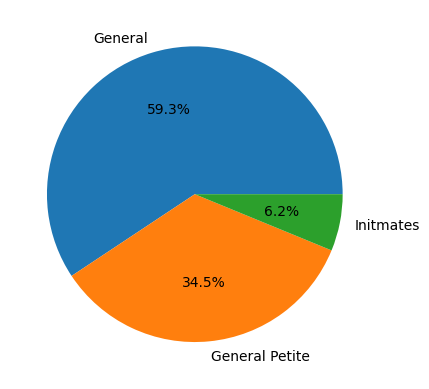

In [9]:
a = data["Division Name"].value_counts()
a
labels = a.index

plt.pie(a, labels=labels, autopct="%.1f%%")
plt.show()


This code creates a pie chart to show the proportion (percentage) of different clothing divisions in your dataset.

    Line Chart : plotting Positive Feedback Count vs Age

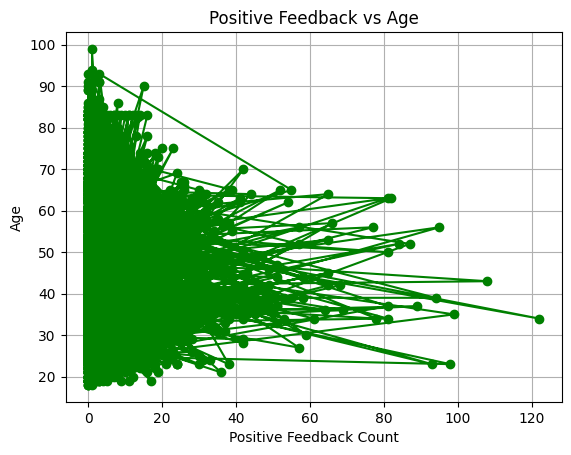

In [11]:

plt.plot(data['Positive Feedback Count'], data['Age'], color='green', marker='o', linestyle='-')

plt.title("Positive Feedback vs Age")
plt.xlabel("Positive Feedback Count")
plt.ylabel("Age")

plt.grid(True)

plt.show()


This code creates a line plot with markers to see if there is any trend between the number of "likes" (Positive Feedback) a review gets and the age of the person who wrote it.

    Heatmap-:   correlation heatmap of numeric columns in your DataFrame

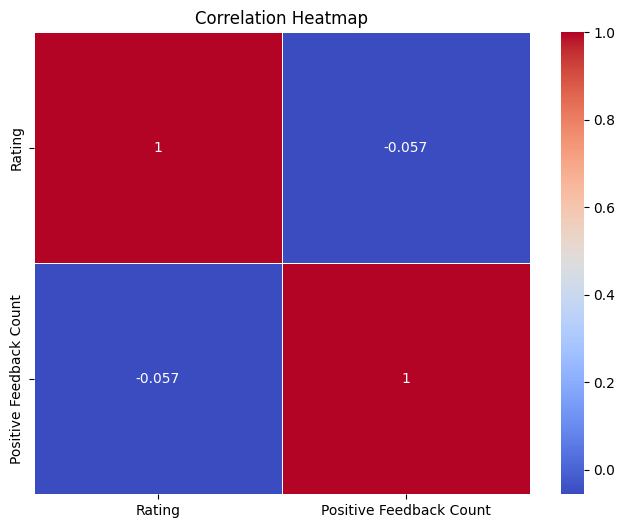

In [14]:
plt.figure(figsize=(8,6))
sns.heatmap(data[['Rating','Positive Feedback Count']].corr(), annot=True, cmap='coolwarm', linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

This code creates a heatmap to show the relationship (correlation) between two numerical values: the Rating and the Positive Feedback Count. It tells you if one goes up when the other one does.

In [37]:
data.head(2)

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants


    A distplot shows how data values are spread using bars and a smooth line.

C:\Users\A\AppData\Local\Temp\ipykernel_5700\2317092479.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data['Age'])


<Axes: xlabel='Age', ylabel='Density'>

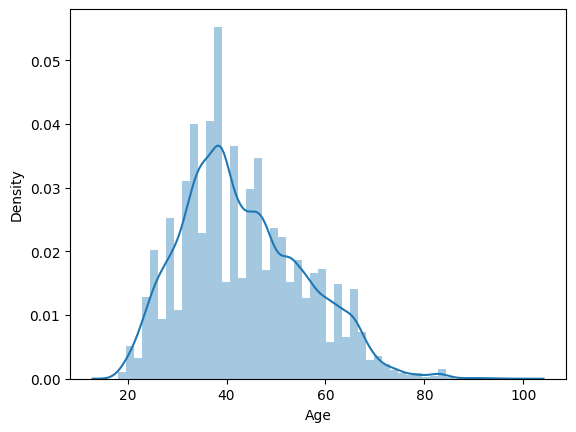

In [15]:
sns.distplot(data['Age'])

It shows the "shape" of your customer's ages using bars and a smooth line.

In [ ]:
    A displot is used to show how data values are distributed in a dataset.

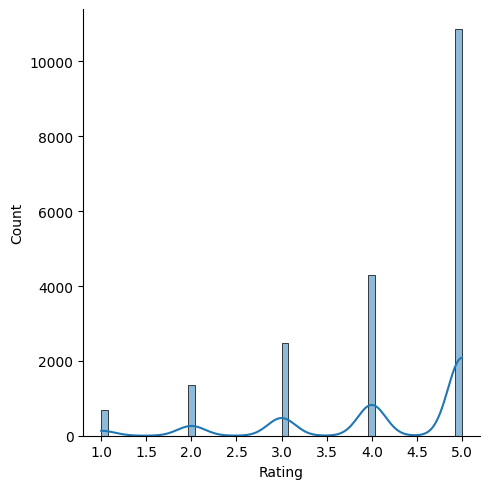

In [40]:
sns.displot(data['Rating'],kde=True)

This code creates a chart to show the spread of your Ratings (from 1 to 5) using bars and a smooth trend line.

    A violin plot shows the distribution of data along with its density.

<Axes: xlabel='Recommended IND', ylabel='Age'>

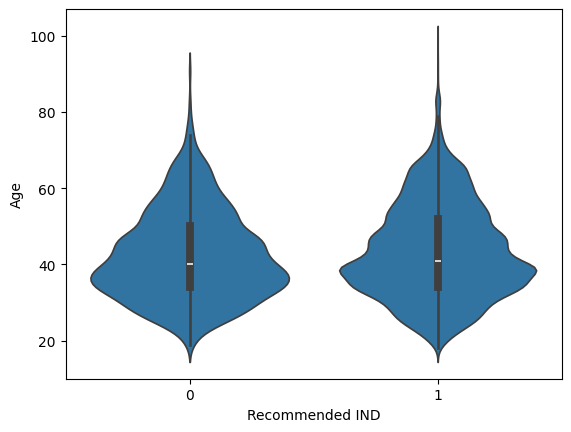

In [16]:
sns.violinplot(data=data, x="Recommended IND", y="Age")


This code creates a violin plot, which is a mix between a boxplot and a density plot. It shows how the Age of customers is spread out for those who recommended the product versus those who did not.

    A joint plot shows the relationship between two numerical variables along with their individual distributions.

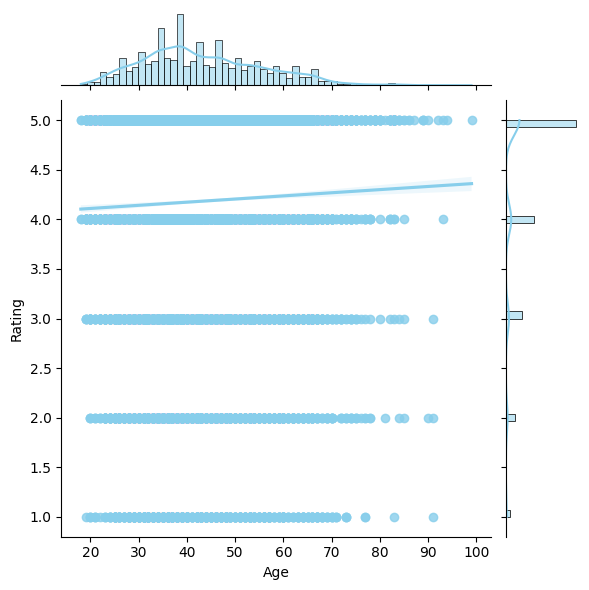

In [41]:
sns.jointplot(data=data, x="Age", y="Rating", kind="reg", color="skyblue")


This code creates a Joint Plot, which is a powerful "2-in-1" chart. It shows the relationship between Age and Rating while also showing how many people are in each group on the sides.

    A pair plot displays pairwise relationships between multiple numerical variables in a dataset.
    It helps in exploratory data analysis (EDA) to understand correlations and patterns.

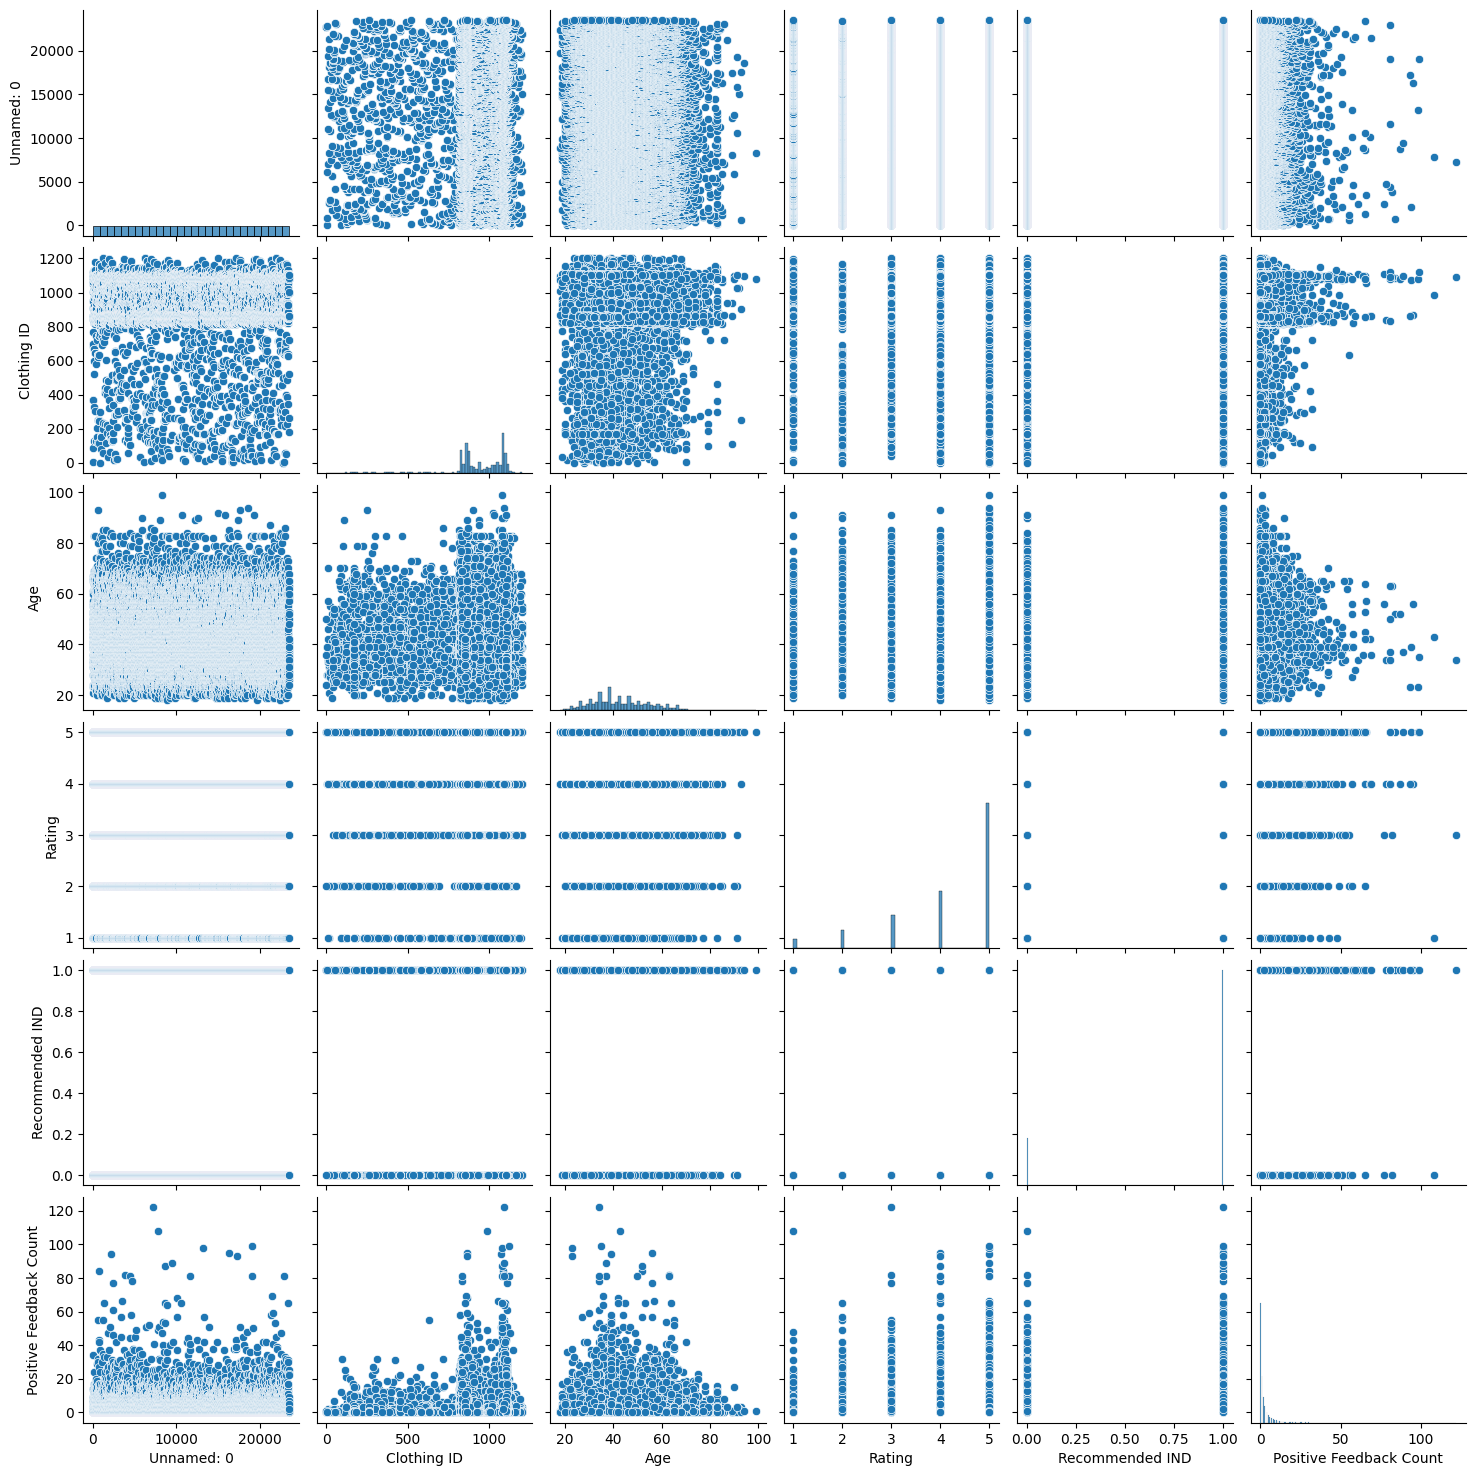

In [20]:
sns.pairplot(data)

Instead of writing code for 10 different charts, this one line gives you all possible combinations at once. It helps you quickly spot patterns, clusters, or weird data points (outliers) across your whole dataset.

In [17]:
data.head(2)

,Unnamed: 0,Clothing ID,Age,Title,Review Text,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name
2,2,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,3,0,0,General,Dresses,Dresses
3,3,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",5,1,0,General Petite,Bottoms,Pants


In [18]:

X = data['Review Text'].astype(str) 
y = data['Recommended IND']

In [19]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC


tfidf = TfidfVectorizer(max_features=1000) 
X_train_tfidf = tfidf.fit_transform(x_train)
X_test_tfidf = tfidf.transform(x_test)

model = SVC(kernel='linear')
model.fit(X_train_tfidf, y_train)


predictions = model.predict(X_test_tfidf)

In [22]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy Score: {accuracy * 100:.2f}%")


print("\nClassification Report:")
print(classification_report(y_test, predictions))

Accuracy Score: 89.35%

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.62      0.67       700
           1       0.92      0.95      0.94      3233

    accuracy                           0.89      3933
   macro avg       0.83      0.79      0.81      3933
weighted avg       0.89      0.89      0.89      3933

